# Salary Prediction Using Linear Regression From Scratch

## Project Overview

In this notebook, we build a Linear Regression model completely **from scratch** without using **Scikit-Learn**.

The objective is to understand how Linear Regression works internally by implementing Gradient Descent manually.

---

## Dataset

- Feature: **YearsExperience**
- Target: **Salary**

---

## Workflow

1. Load Data
2. Exploratory Data Analysis (EDA)
3. Data Visualization
4. Prepare Features & Target
5. Train/Test Split
6. Initialize Parameters
7. Train Using Gradient Descent
8. Make Predictions
9. Evaluate the Model
10. Visualize Results
11. Conclusion

In [61]:
#---------------
# 1. Import Library
#--------------
from  pandas import read_csv,DataFrame
import matplotlib.pyplot as plt
from numpy import sqrt
from sklearn.model_selection import train_test_split

In [62]:
#---------------
# 2. Load Dataset
#--------------
dataFrame = read_csv('Salary_Data.csv')

In [63]:
#---------------
# 3. Display First Rows
#--------------
display(dataFrame.head())

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [64]:
#---------------
# 3.  Dataset Information
#--------------
display(dataFrame.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


None

In [65]:
#---------------
# 3.  Check Empty Value, If Found Empty Value Remove It
#--------------
emptyValues = dataFrame.isna().sum()
if emptyValues.sum() > 0:
    dataFrame.dropna(axis=1,inplace=true)
print(f"Empty Values counts is {emptyValues}")

Empty Values counts is YearsExperience    0
Salary             0
dtype: int64


In [66]:
#---------------
# 3.  Remove Duplicated Value
#--------------
# display(dataFrame.drop_duplicates().sum())
duplicatedVal = dataFrame.duplicated().sum()
if duplicatedVal > 0:
    df = dataFrame.drop_duplicates()
print(f"Count of Duplicated Value {duplicatedVal}")

Count of Duplicated Value 0


In [67]:
#---------------
# 4. Statistical Summary
#--------------
display(dataFrame.describe())

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


## Data Cleaning Summary

After exploring the dataset, we found that it is clean and ready for training.

- ✅ No missing values were detected.
- ✅ No duplicate records were found.
- ✅ Data types are correct.
- ✅ No invalid values were found (e.g., negative salary or negative years of experience).
- ✅ The data was visualized to understand the relationship between the feature and the target.

If the dataset had contained missing values, duplicates, or invalid values, data cleaning would have been required before training the model.

Since the dataset is already clean, we can now prepare the input feature (`X`) and the target variable (`y`).

In [68]:
#---------------
# 5. Correlation Between Target and Features
#---------------
corr = dataFrame.corr(numeric_only=True)
print(f"Correlation between YearsExperience and Salary = {corr}")

Correlation between YearsExperience and Salary =                  YearsExperience    Salary
YearsExperience         1.000000  0.978242
Salary                  0.978242  1.000000


## Correlation Analysis

The correlation coefficient between **YearsExperience** and **Salary** is **0.978**.

Since the value is very close to **1**, this indicates a **strong positive linear relationship** between the two variables.

This suggests that **Linear Regression** is an appropriate model for this dataset.

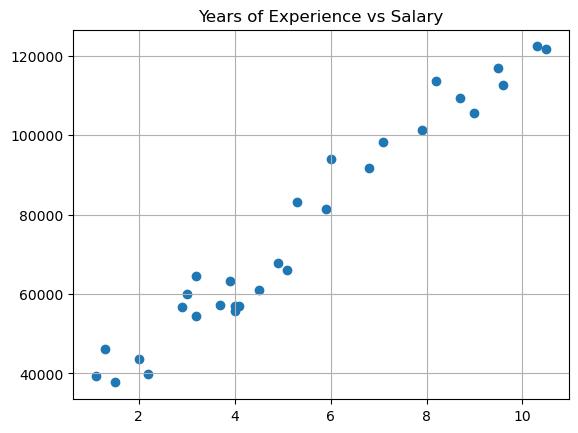

In [69]:
#---------------
# 6. Visualize the Relationship Between Years of Experience and Salary
#---------------
salary = dataFrame["Salary"]
yearsOfExperience = dataFrame["YearsExperience"]

plt.scatter(
    yearsOfExperience,
    salary
)

plt.title("Years of Experience vs Salary")

plt.grid(True)

plt.show()

In [70]:
#---------------
# 6. Prepare Features and Target
#---------------

X = dataFrame["YearsExperience"]
y = dataFrame["Salary"]

print(f"Feature Shape : {X.shape}")
print(f"Target Shape  : {y.shape}")

display(X.head())
display(y.head())

Feature Shape : (30,)
Target Shape  : (30,)


0    1.1
1    1.3
2    1.5
3    2.0
4    2.2
Name: YearsExperience, dtype: float64

0    39343
1    46205
2    37731
3    43525
4    39891
Name: Salary, dtype: int64

In [71]:
#-----------------------
# 7. Split Dataset
#-----------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    shuffle=True,
)

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

Training Samples : 22
Testing Samples  : 8


In [72]:
#---------------------------------
# 7. Initialize Model Parameters
#---------------------------------

theta0 = 0.0
theta1 = 0.0

learning_rate = 0.01
iteration = 0
previous_mse = float("inf")
m = len(X_train)

In [73]:
#---------------------------------
# 8. Calculate Prediction
#---------------------------------

y_hat = theta0 + theta1 * X_train

print(y_hat.head())

12    0.0
0     0.0
4     0.0
16    0.0
5     0.0
Name: YearsExperience, dtype: float64


# Model Training

In this step, we train the Linear Regression model from scratch using **Gradient Descent**.

The algorithm works iteratively by:

1. Predicting the output using the current parameters.
2. Calculating the prediction error.
3. Computing the gradients of the cost function.
4. Updating the model parameters.
5. Repeating the process until the model converges.

In [74]:
while True:

    # Prediction
    y_hat = theta0 + theta1 * X_train

    # Error
    error = y_hat - y_train

    # Mean Squared Error (Cost Function)
    mse = (error ** 2).mean()

    # Calculate Gradients
    d_theta0 = (2 / m) * error.sum()
    d_theta1 = (2 / m) * (error * X_train).sum()

    # Update Parameters
    theta0 = theta0 - learning_rate * d_theta0
    theta1 = theta1 - learning_rate * d_theta1

    # Print Training Progress
    if iteration % 100 == 0:
        print(
            f"Iteration: {iteration:4} | "
            f"MSE: {mse:.2f} | "
            f"Theta0: {theta0:.4f} | "
            f"Theta1: {theta1:.4f}"
        )

    # Stop Training if MSE Converges
    if abs(previous_mse - mse) < 0.0001:
        print("\nTraining Finished Successfully!")
        break

    previous_mse = mse
    iteration += 1

print("\nFinal Parameters")
print(f"Theta0 = {theta0:.6f}")
print(f"Theta1 = {theta1:.6f}")

Iteration:    0 | MSE: 5615964344.41 | Theta0: 1408.3282 | Theta1: 8094.2215
Iteration:  100 | MSE: 80616060.59 | Theta0: 10845.3671 | Theta1: 11716.4368
Iteration:  200 | MSE: 49615425.31 | Theta0: 16275.6419 | Theta1: 10846.0419
Iteration:  300 | MSE: 37354355.73 | Theta0: 19690.7205 | Theta1: 10298.6541
Iteration:  400 | MSE: 32504976.81 | Theta0: 21838.4499 | Theta1: 9954.4040
Iteration:  500 | MSE: 30586997.65 | Theta0: 23189.1486 | Theta1: 9737.9064
Iteration:  600 | MSE: 29828417.20 | Theta0: 24038.5976 | Theta1: 9601.7520
Iteration:  700 | MSE: 29528390.84 | Theta0: 24572.8128 | Theta1: 9516.1250
Iteration:  800 | MSE: 29409727.34 | Theta0: 24908.7786 | Theta1: 9462.2745
Iteration:  900 | MSE: 29362794.70 | Theta0: 25120.0662 | Theta1: 9428.4081
Iteration: 1000 | MSE: 29344232.36 | Theta0: 25252.9441 | Theta1: 9407.1097
Iteration: 1100 | MSE: 29336890.77 | Theta0: 25336.5105 | Theta1: 9393.7152
Iteration: 1200 | MSE: 29333987.09 | Theta0: 25389.0651 | Theta1: 9385.2915
Iteratio

In [75]:
#-----------------------
# 9. Predict Test Data
#-----------------------

y_pred = theta0 + theta1 * X_test

display(y_pred.head())

27    115439.995710
15     71396.060852
23    102320.525752
17     75144.480840
8      55465.275904
Name: YearsExperience, dtype: float64

In [76]:
#-----------------------
# 9. Compare Model Result With Actual Data
#-----------------------
comparison = DataFrame({
    "YearsExperience": X_test,
    "Actual Salary": y_test,
    "Predicted Salary": y_pred
})

comparison["Error"] = comparison["Predicted Salary"] - comparison["Actual Salary"]
comparison["Absolute Error"] = comparison["Error"].abs()
comparison["Percentage Error"] = (
    comparison["Absolute Error"] / comparison["Actual Salary"]
) * 100
comparison

,YearsExperience,Actual Salary,Predicted Salary,Error,Absolute Error,Percentage Error
27,9.6,112635,115439.995710,2804.995710,2804.995710,2.490341
15,4.9,67938,71396.060852,3458.060852,3458.060852,5.090025
23,8.2,113812,102320.525752,-11491.474248,11491.474248,10.096892
17,5.3,83088,75144.480840,-7943.519160,7943.519160,9.560369
8,3.2,64445,55465.275904,-8979.724096,8979.724096,13.933935
9,3.7,57189,60150.800889,2961.800889,2961.800889,5.178970
28,10.3,122391,121999.730689,-391.269311,391.269311,0.319688
24,8.7,109431,107006.050737,-2424.949263,2424.949263,2.215962


In [77]:
#-----------------------
# Evaluation
#-----------------------

# R²
ss_res = ((y_test - y_pred) ** 2).sum()
ss_tot = ((y_test - y_test.mean()) ** 2).sum()

r2 = 1 - (ss_res / ss_tot)

# MAE
mae = abs(y_test - y_pred).mean()

# RMSE
rmse = sqrt(((y_test - y_pred) ** 2).mean())

print(f"R²   = {r2:.4f}")
print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")

R²   = 0.9347
MAE  = 5056.97
RMSE = 6229.17


# Model Evaluation

The model was evaluated using three common regression metrics:

- **R² Score** measures how well the model explains the variance in the target variable.
- **MAE (Mean Absolute Error)** measures the average prediction error.
- **RMSE (Root Mean Squared Error)** measures the prediction error while penalizing larger mistakes more heavily.

Together, these metrics provide a comprehensive understanding of the model's performance.

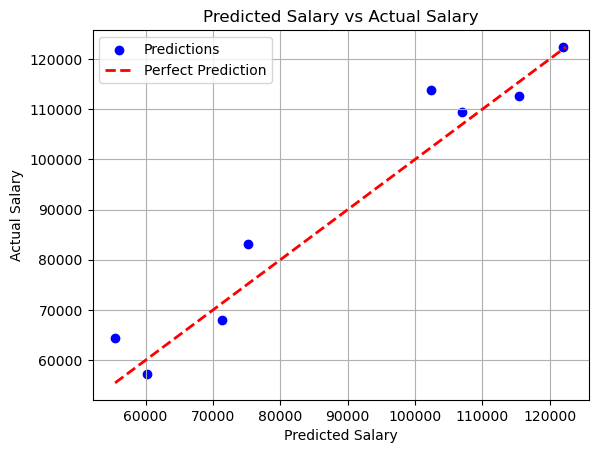

In [78]:
#-----------------------
# 9. Visualize Predicted vs Actual Salary
#-----------------------
plt.scatter(y_pred, y_test, color="blue", label="Predictions")

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    "r--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Predicted Salary")
plt.ylabel("Actual Salary")
plt.title("Predicted Salary vs Actual Salary")

plt.legend()
plt.grid(True)

plt.show()

# Conclusion

In this project, we successfully implemented **Linear Regression from scratch** without relying on Scikit-Learn.

The model was trained using **Gradient Descent**, and the learned parameters were used to predict salaries based on years of experience.

The evaluation metrics indicate that the model performs well on unseen data, making Linear Regression a suitable choice for this dataset.

This project also demonstrates the complete machine learning workflow, including:

- Data exploration
- Data visualization
- Data preparation
- Model training
- Model evaluation
- Prediction analysis

# Future Work

Possible improvements for this project include:

- Extend the implementation to Multiple Linear Regression.
- Compare the manual implementation with Scikit-Learn.
- Add Feature Scaling experiments.
- Experiment with Polynomial Regression.
- Implement Regularization techniques (Ridge and Lasso).
- Apply the model to larger real-world datasets.